# Part 1: Practical Implementation


### Task 1: Load the Dataset 


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("customer_churn_dataset-testing-master.csv")
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [3]:
df.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.shape

(64374, 12)

# Task 2: Dataset Exploration


In [5]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [6]:
df.dtypes

CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

In [7]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


# Task 3: Target Variable Analysis


In [10]:
# Target variable
y = df["Churn"]

# Features
X = df.drop("Churn", axis=1)

In [11]:
print(df["Churn"].value_counts())


Churn
0    33881
1    30493
Name: count, dtype: int64


## Conclusion

##### ✅ This is a balanced dataset because both classes have similar numbers of observations.

In [12]:
churn_percentage = (df["Churn"].value_counts(normalize=True) * 100)

print(churn_percentage)

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


# Task 4: Train-Test Split


In [14]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42  )

In [18]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
dtypes: int64(8), object(3)
memory usage: 5.4+ MB


# Task 5: Feature Selection


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
ct = ColumnTransformer(transformers=[

    ("oh", OneHotEncoder(drop='first'), [2,7,8]),

    ("sc", StandardScaler(), [1,3,4,5,6,9,10])

], remainder='passthrough')

# Apply transformations
X_transformed = ct.fit_transform(X)


In [25]:
X_train_transform=ct.fit_transform(X_train)
X_train_transform=pd.DataFrame(X_train_transform)
X_train_transform

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,1.0,1.007489,0.586916,-0.461726,-1.733835,-0.805979,0.968288,-0.057826,13469.0
1,1.0,0.0,1.0,0.0,1.0,0.864009,1.639129,-1.142305,-0.770040,-0.918834,0.266576,0.984556,20119.0
2,1.0,0.0,0.0,0.0,0.0,-0.786001,-1.166770,-1.482595,1.157549,-1.144543,-1.221206,1.679478,48412.0
3,0.0,1.0,0.0,1.0,0.0,-0.642522,-0.582208,0.218853,-0.127510,0.886844,0.412287,0.521275,42126.0
4,0.0,1.0,0.0,1.0,0.0,-0.212084,-0.231471,1.693442,-1.091305,0.886844,1.696841,0.752916,55120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51494,1.0,1.0,0.0,0.0,1.0,0.577051,0.353092,-0.461726,-0.127510,1.225408,0.105528,-1.216028,62571.0
51495,1.0,1.0,0.0,1.0,0.0,0.792270,0.703829,1.693442,-0.770040,-1.595963,-0.358445,0.637096,38159.0
51496,0.0,0.0,1.0,0.0,1.0,-0.642522,0.879198,-0.688586,-1.091305,0.999699,-0.331604,-1.100208,861.0
51497,1.0,1.0,0.0,0.0,0.0,-1.288178,1.463760,0.445713,1.478814,-0.918834,1.562634,1.332017,15796.0


In [26]:
X_test_transform=ct.fit_transform(X_test)
X_test_transform=pd.DataFrame(X_test_transform)
X_test_transform

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,0.0,1.0,1.0,0.0,0.935372,-0.711223,1.007183,-0.453932,-1.259282,0.351471,1.097890,15477.0
1,1.0,1.0,0.0,0.0,1.0,-1.011768,-0.300966,1.687622,-0.453932,-1.372702,0.336157,-0.635103,34667.0
2,0.0,1.0,0.0,0.0,1.0,1.656535,1.633103,0.213337,0.507894,-0.125083,-0.877525,-1.674900,50475.0
3,1.0,1.0,0.0,0.0,0.0,0.791139,0.871197,0.099930,0.828502,-1.145862,-0.062023,-0.288505,7985.0
4,1.0,1.0,0.0,0.0,0.0,-0.723302,1.398671,-1.147543,0.507894,-0.238503,-1.176159,1.097890,20228.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12870,1.0,1.0,0.0,0.0,0.0,-0.002140,1.398671,0.213337,-0.133323,-0.351923,-0.127110,0.404693,15816.0
12871,0.0,0.0,1.0,0.0,1.0,1.440186,-1.824778,0.893776,-1.095149,0.215176,1.588125,-1.443834,23038.0
12872,0.0,1.0,0.0,0.0,1.0,0.719023,1.047022,-0.920729,-0.133323,1.235955,1.255033,-1.097235,55567.0
12873,0.0,0.0,1.0,0.0,0.0,-1.588698,1.398671,1.120589,-0.453932,0.328596,0.933426,0.866824,22750.0


# Task 6: Data Preprocessing


In [23]:
# Mutual Information
mi_scores = mutual_info_classif(X_transformed, y)

# Feature names
feature_names = ct.get_feature_names_out()

# Create dataframe
mi_df = pd.DataFrame({
    "Feature": feature_names,
    "MI Score": mi_scores
})

# Sort scores
mi_df = mi_df.sort_values(by="MI Score", ascending=False)

# Display
print(mi_df)

                           Feature  MI Score
12           remainder__CustomerID  0.286534
9                sc__Payment Delay  0.209295
8                sc__Support Calls  0.065905
6                       sc__Tenure  0.028565
0                  oh__Gender_Male  0.017639
7              sc__Usage Frequency  0.016987
5                          sc__Age  0.005530
11            sc__Last Interaction  0.003993
10                 sc__Total Spend  0.003049
2   oh__Subscription Type_Standard  0.002458
4    oh__Contract Length_Quarterly  0.002092
1    oh__Subscription Type_Premium  0.001100
3      oh__Contract Length_Monthly  0.000497


# Task 5: Feature Selection

In [27]:
print("Shape of Feature Matrix (X):", X.shape)
print("Shape of Target Variable (y):", y.shape)

Shape of Feature Matrix (X): (64374, 11)
Shape of Target Variable (y): (64374,)


# Task 7: Model Building


In [29]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train_transform, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred = lr.predict(X_test_transform)

# Task 8: Model Prediction


In [31]:
print("Predicted Values:\n")
print(y_pred)

Predicted Values:

[0 0 1 ... 1 0 0]


# Task 9: Model Evaluation

In [32]:
from sklearn.metrics import (accuracy_score,confusion_matrix,precision_score,recall_score,f1_score)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

Accuracy Score: 0.8654757281553398


In [34]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)


Confusion Matrix:

[[5930  863]
 [ 869 5213]]


In [35]:
precision = precision_score(y_test, y_pred)

print("\nPrecision Score:", precision)


Precision Score: 0.857965766951942


In [36]:
recall = recall_score(y_test, y_pred)

print("\nRecall Score:", recall)


Recall Score: 0.8571193686287405


In [37]:
f1 = f1_score(y_test, y_pred)

print("\nF1 Score:", f1)


F1 Score: 0.8575423589406153


#  Task 10: ROC-AUC Analysis

ROC-AUC Score: 0.9411205985928704


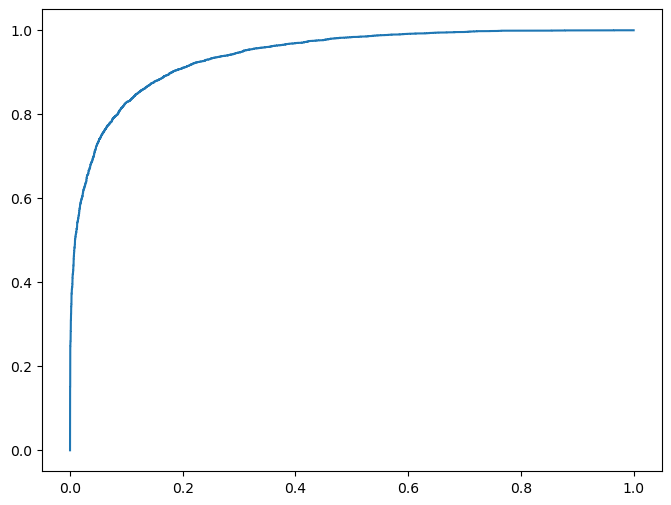

In [39]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_prob = lr.predict_proba(X_test_transform)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

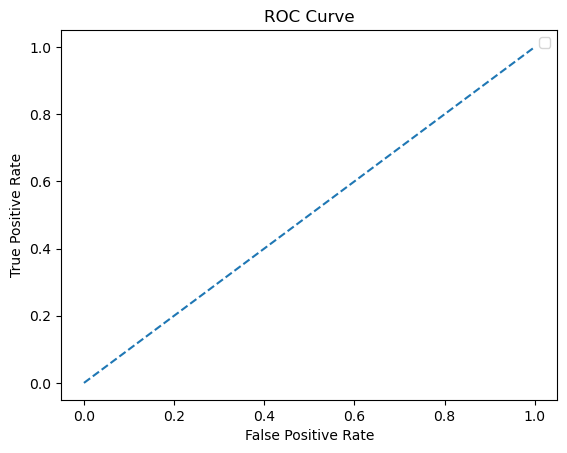

In [40]:
# Diagonal line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

# Part 2: Interview-Oriented Theoretical Questions

### 1.What is Logistic Regression?
##### Logistic Regression is a supervised learning algorithm used for classification problems. It predicts the probability of a class using the sigmoid function.
### 2.Why is Logistic Regression called a regression algorithm even though it is used for classification?
##### It is called regression because it estimates probabilities using a regression equation. The final output is then converted into classes.
### What is the Sigmoid Function? Write its mathematical formula.
##### The sigmoid function converts values into probabilities between 0 and 1.
##### σ(z)=1/1+e−z1
### 3.Why do we use the sigmoid function in logistic regression?
##### The sigmoid function maps predictions into probability values between 0 and 1. This makes it suitable for binary classification.
### 4.What are Odds and Log Odds (Logit)?
##### Odds represent the ratio of success probability to failure probability. Log Odds (logit) is the logarithm of the odds used in logistic regression.
### 5.What is a decision boundary in logistic regression?
##### A decision boundary separates classes based on predicted probability. Usually, probability greater than 0.5 is classified as class 1.
### 6.Why can't Mean Squared Error (MSE) be used as a cost function in logistic regression?
##### MSE creates a non-convex optimization problem for logistic regression. Log Loss is preferred because it provides better convergence.
### 7.What is Log Loss (Binary Cross Entropy)?
#####  Log Loss measures how far predicted probabilities are from actual labels. Lower log loss means better predictions.
### 8.What are the assumptions of Logistic Regression?
##### Logistic Regression assumes independent observations, little multicollinearity, and a linear relationship between features and log odds.
### 9.What is multicollinearity, and why is it a problem?
##### Multicollinearity occurs when independent variables are highly correlated. It makes coefficient estimates unstable and harder to interpret.
### 10.What is Variance Inflation Factor (VIF)?
##### VIF measures how much multicollinearity exists among features. Higher VIF values indicate stronger correlation between variables.
### 11.What evaluation metrics are commonly used for classification models?
##### Common metrics include Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.
### 12.Explain the difference between Precision, Recall, and F1 Score.
##### Precision measures correctness of positive predictions, Recall measures how many actual positives are detected, and F1 Score balances both.
### 13.What is a Confusion Matrix?
##### A Confusion Matrix is a table showing correct and incorrect predictions. It includes TP, TN, FP, and FN values.
### 14.What is the ROC Curve?
#####  ROC Curve plots True Positive Rate against False Positive Rate at different thresholds. It evaluates classifier performance.
### 15.What does AUC score represent?
##### AUC measures the overall ability of the model to separate classes. Higher AUC means better classification performance.
### 16.What problems arise when the dataset is imbalanced?
##### Models may become biased toward the majority class and ignore minority cases. Accuracy can become misleading.
### 17.What techniques can be used to handle imbalanced datasets?
##### Techniques include SMOTE, undersampling, oversampling, class weighting, and balanced evaluation metrics like F1-score.
### 18.Explain the difference between Logistic Regression and Linear Regression.
##### Linear Regression predicts continuous values, while Logistic Regression predicts probabilities for classification tasks.
### 19.What is Regularization in Logistic Regression?
#####  Regularization prevents overfitting by adding a penalty term to the loss function. It improves model generalization.
###  20.Explain the difference between L1 and L2 Regularization.
#####  L1 regularization can reduce some coefficients to zero for feature selection. L2 regularization shrinks coefficients but usually does not eliminate them.
### 21.When should Logistic Regression be preferred over other machine learning algorithms?
##### Use Logistic Regression when the dataset is simple, interpretable, and linearly separable. It works well for baseline classification models.